# Inside a Spiking Neural Network: The Forward Pass

We've seen how a single CUBA-LIF neuron works. Now let's connect many of them into a **feedforward spiking neural network** and watch what happens when we feed it a single MNIST digit.

The network has:
- **784 input neurons** (one per pixel) — spikes generated via Bernoulli encoding
- **32 hidden LIF neurons** — connected to inputs through learned weights
- **10 output LIF neurons** — one per digit class

The weights are **random** (untrained), so the network won't classify correctly — the goal here is to understand the **mechanics of the forward pass**, not accuracy.

We will visualize the spike rasters at each layer to see how information flows through the network.

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor

## Model Components

We reuse the `CUBAPointLeaky` neuron from the previous notebook.

In [11]:
class CUBAPointLeaky(nn.Module):
    """Current-Based Leaky Integrate-and-Fire neuron."""
    def __init__(self, threshold, reset, tau_mem, tau_syn, R, dt):
        super().__init__()
        self.threshold = threshold
        self.reset = reset
        self.alpha_mem = torch.exp(torch.tensor(-dt / tau_mem))
        self.alpha_syn = torch.exp(torch.tensor(-dt / tau_syn))
        self.voltage_scale = R * (1.0 - self.alpha_mem)

    def initialize_state(self, batch_size, num_neurons, device):
        shape = (batch_size, num_neurons)
        return torch.zeros(shape, device=device), torch.zeros(shape, device=device)

    def forward(self, x, state):
        mem, isyn = state
        new_isyn = self.alpha_syn * isyn + x
        new_mem = self.alpha_mem * mem + self.voltage_scale * new_isyn
        spike = (new_mem > self.threshold).float()
        mem = new_mem * (1 - spike) + self.reset * spike
        return spike, (mem, new_isyn)

## Building the Network

The network is a simple two-layer feedforward SNN. Unlike a standard ANN where each layer computes one output per input, here each layer **runs for many timesteps**. At each timestep:

1. Input spikes are sampled from pixel probabilities (Bernoulli)
2. These are multiplied by the hidden-layer weights → synaptic input to hidden neurons
3. Hidden LIF neurons update their state and may spike
4. Hidden spikes are multiplied by output-layer weights → synaptic input to output neurons
5. Output LIF neurons update their state and may spike

The classification decision is based on which output neuron spikes the most over all timesteps.

For this demo, we modify the network to **record spikes at every layer** so we can visualize them.

In [12]:
class CUBAPointSurrogateNet(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs, num_steps,
                 threshold, reset, tau_mem, tau_syn, R, dt):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.num_steps = num_steps

        self.weights_hidden = nn.Linear(num_inputs, num_hidden)
        self.lif_hidden = CUBAPointLeaky(
            threshold=threshold, reset=reset, R=R,
            tau_mem=tau_mem, tau_syn=tau_syn, dt=dt)

        self.weights_out = nn.Linear(num_hidden, num_outputs)
        self.lif_out = CUBAPointLeaky(
            threshold=threshold, reset=reset, R=R,
            tau_mem=tau_mem, tau_syn=tau_syn, dt=dt)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        B = x.size(0)

        mem_hidden, isyn_hidden = self.lif_hidden.initialize_state(B, self.num_hidden, x.device)
        mem_out, isyn_out = self.lif_out.initialize_state(B, self.num_outputs, x.device)

        # Record spikes at every layer and timestep
        rec_hidden = []
        rec_output = []

        for step in range(self.num_steps):
            spk_input = torch.bernoulli(x)

            cur_hidden = self.weights_hidden(spk_input)
            spk_hidden, (mem_hidden, isyn_hidden) = self.lif_hidden(
                cur_hidden, (mem_hidden, isyn_hidden))
            rec_hidden.append(spk_hidden)

            cur_out = self.weights_out(spk_hidden)
            spk_out, (mem_out, isyn_out) = self.lif_out(
                cur_out, (mem_out, isyn_out))
            rec_output.append(spk_out)

        # Stack: (num_steps, batch, neurons)
        return {
            'hidden': torch.stack(rec_hidden),
            'output': torch.stack(rec_output),
        }

## Setup

In [13]:
# Parameters (same as the training pipeline)
DT        = 1e-3
TIME      = 30e-3
THRESHOLD = 1.0
RESET     = 0.0
R         = 6
TAU_MEM   = 10e-3
TAU_SYN   = 2e-3
NUM_STEPS = int(TIME / DT)  # 30 steps
INPUT_SCALE = 1.0

NUM_INPUTS  = 784
NUM_HIDDEN  = 32
NUM_OUTPUTS = 10

torch.manual_seed(42)

network = CUBAPointSurrogateNet(
    num_inputs=NUM_INPUTS, num_hidden=NUM_HIDDEN, num_outputs=NUM_OUTPUTS,
    num_steps=NUM_STEPS, threshold=THRESHOLD, reset=RESET,
    R=R, tau_mem=TAU_MEM, tau_syn=TAU_SYN, dt=DT)

print(f"Simulation: {NUM_STEPS} timesteps ({TIME*1000:.0f} ms)")
print(f"Network: {NUM_INPUTS} → {NUM_HIDDEN} → {NUM_OUTPUTS}")
print(f"Total parameters: {sum(p.numel() for p in network.parameters()):,}")

Simulation: 30 timesteps (30 ms)
Network: 784 → 32 → 10
Total parameters: 25,450


## Weight Initialization

PyTorch's `nn.Linear` initializes weights using **Kaiming uniform** by default — values are drawn uniformly from $\left[-\frac{1}{\sqrt{n_{in}}}, \frac{1}{\sqrt{n_{in}}}\right]$ where $n_{in}$ is the number of input features. This keeps the variance of activations stable across layers.

Let's look at the distribution of the randomly initialized weights in both layers:

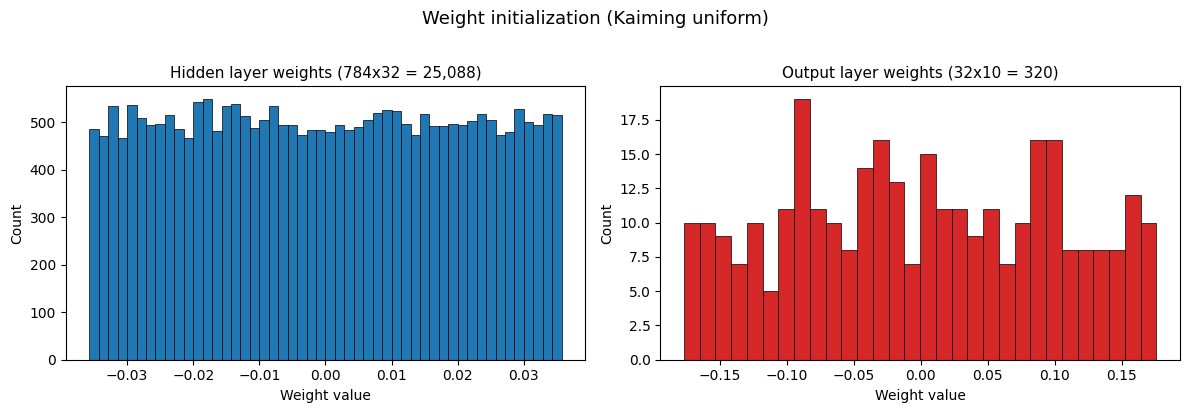

Hidden weights — range: [-0.0357, 0.0357], std: 0.0206
Output weights — range: [-0.1765, 0.1758], std: 0.0980


In [14]:
w_hidden = network.weights_hidden.weight.data.flatten().numpy()
w_output = network.weights_out.weight.data.flatten().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(w_hidden, bins=50, color='C0', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Weight value')
ax1.set_ylabel('Count')
ax1.set_title(f'Hidden layer weights ({NUM_INPUTS}x{NUM_HIDDEN} = {NUM_INPUTS*NUM_HIDDEN:,})', fontsize=11)

ax2.hist(w_output, bins=30, color='C3', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Weight value')
ax2.set_ylabel('Count')
ax2.set_title(f'Output layer weights ({NUM_HIDDEN}x{NUM_OUTPUTS} = {NUM_HIDDEN*NUM_OUTPUTS:,})', fontsize=11)

fig.suptitle('Weight initialization (Kaiming uniform)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print(f"Hidden weights — range: [{w_hidden.min():.4f}, {w_hidden.max():.4f}], std: {w_hidden.std():.4f}")
print(f"Output weights — range: [{w_output.min():.4f}, {w_output.max():.4f}], std: {w_output.std():.4f}")

## Load a Single Digit

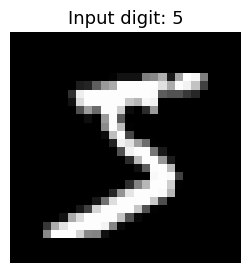

In [15]:
data = datasets.MNIST(root='./data', train=True, download=True, transform=ToTensor())

# Pick a sample
sample_idx = 0
img, label = data[sample_idx]

# Normalize to spike probabilities
img = img.float() / img.max()
dt_input_scale = INPUT_SCALE * (DT / 1e-3)
img = img * dt_input_scale

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Input digit: {label}', fontsize=13)
plt.axis('off')
plt.show()

## Run the Forward Pass

We feed the single digit through the network (with random weights) and collect spike recordings at every layer.

In [16]:
# Add batch dimension: (1, 1, 28, 28)
with torch.no_grad():
    recordings = network(img.unsqueeze(0))

# Remove batch dimension: (num_steps, neurons)
spk_hidden = recordings['hidden'][:, 0, :]
spk_output = recordings['output'][:, 0, :]

print(f"Hidden spikes: {spk_hidden.shape}  — total: {spk_hidden.sum().item():.0f}")
print(f"Output spikes: {spk_output.shape}  — total: {spk_output.sum().item():.0f}")

Hidden spikes: torch.Size([30, 32])  — total: 74
Output spikes: torch.Size([30, 10])  — total: 8


## Spike Raster Plots

A **raster plot** shows when each neuron spikes: each row is a neuron, each dot is a spike at a particular timestep. We plot all three layers stacked vertically to see how activity propagates through the network.

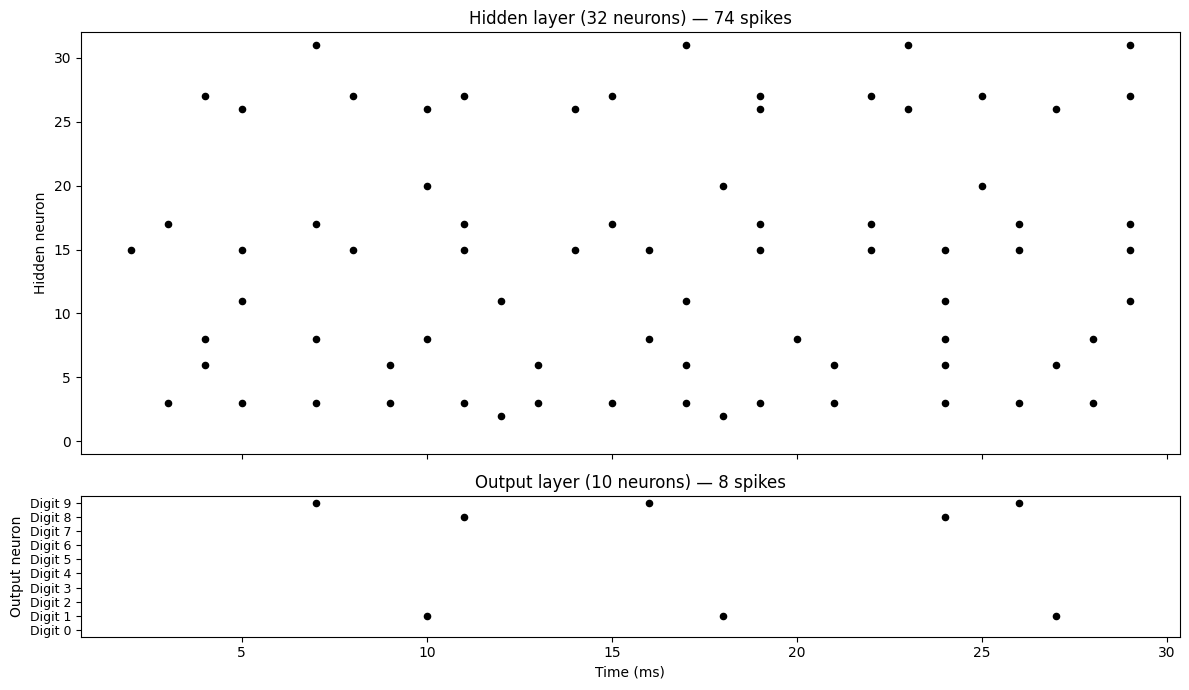

In [17]:
time_ms = torch.arange(NUM_STEPS) * DT * 1000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Hidden layer raster (32 neurons)
t_idx, n_idx = torch.where(spk_hidden.T > 0)
ax1.scatter(time_ms[n_idx], t_idx, s=20, color='black', marker='o')
ax1.set_ylabel('Hidden neuron')
ax1.set_title(f'Hidden layer ({NUM_HIDDEN} neurons) — {spk_hidden.sum().item():.0f} spikes', fontsize=12)
ax1.set_ylim(-1, NUM_HIDDEN)

# Output layer raster (10 neurons)
t_idx, n_idx = torch.where(spk_output.T > 0)
ax2.scatter(time_ms[n_idx], t_idx, s=20, color='black', marker='o')
ax2.set_ylabel('Output neuron')
ax2.set_title(f'Output layer ({NUM_OUTPUTS} neurons) — {spk_output.sum().item():.0f} spikes', fontsize=12)
ax2.set_ylim(-0.5, NUM_OUTPUTS - 0.5)
ax2.set_yticks(range(NUM_OUTPUTS))
ax2.set_yticklabels([f'Digit {i}' for i in range(NUM_OUTPUTS)], fontsize=9)
ax2.set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()

## Output Spike Counts

In a trained network, the output neuron corresponding to the correct digit would spike the most. With random weights, the spike counts are essentially arbitrary — but the **mechanism** is the same: the class with the most output spikes wins.

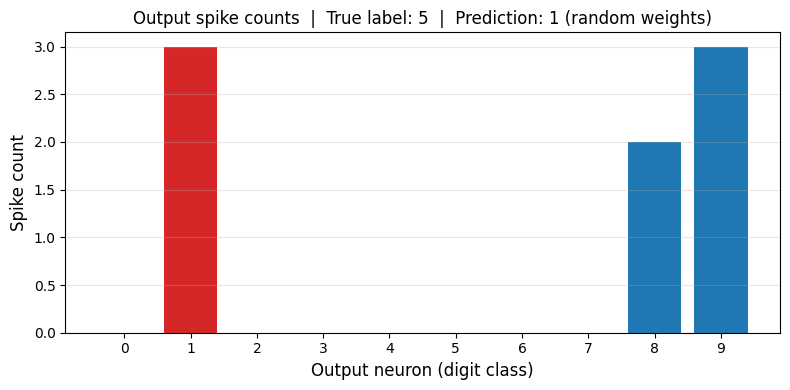

In [18]:
spike_counts = spk_output.sum(dim=0)
predicted = spike_counts.argmax().item()

colors = ['C3' if i == predicted else 'C0' for i in range(NUM_OUTPUTS)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(NUM_OUTPUTS), spike_counts.numpy(), color=colors)
ax.set_xticks(range(NUM_OUTPUTS))
ax.set_xlabel('Output neuron (digit class)', fontsize=12)
ax.set_ylabel('Spike count', fontsize=12)
ax.set_title(f'Output spike counts  |  True label: {label}  |  Prediction: {predicted} (random weights)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## Summary

This notebook showed the complete **forward pass** of a feedforward SNN:

1. **Input encoding**: pixel intensities are converted to stochastic spike trains via Bernoulli sampling at each timestep
2. **Hidden layer**: input spikes are weighted, summed, and fed into LIF neurons that produce their own spikes
3. **Output layer**: hidden spikes are weighted, summed, and fed into output LIF neurons
4. **Decision**: the output neuron with the most spikes over all timesteps determines the predicted class

With random weights the prediction is meaningless — but the architecture and dynamics are identical to what we will train in the next notebook using **surrogate gradients**.